# ✅ Heart Disease Prediction - Playground Series S6E2

**Competition Goal:** Predict the presence of heart disease using clinical measurements with ROC-AUC optimization.

**Approach:**
- Multi-seed ensemble (3 seeds) with CatBoost for robust predictions
- Extensive feature engineering: frequency encoding, target statistics, transformations
- 5-fold stratified cross-validation
- 57 engineered features from 13 original features

## 1. Import Libraries

In [1]:
import time
from copy import deepcopy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit, KFold, StratifiedKFold
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, RobustScaler, OrdinalEncoder, LabelEncoder, KBinsDiscretizer
from sklearn.metrics import roc_auc_score, roc_curve, auc
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

In [2]:
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'accent': '#f093fb',
    'highlight': '#4facfe',
    'dark': '#2d3561',
    'light': '#e0c3fc'
}

GRADIENT = ['#667eea', '#764ba2', '#a855f7', '#f093fb', '#fbc2eb']

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(GRADIENT)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load Data

In [3]:
ADD_EXTERN_DATA = False
STRAT = False
EXTENDED_STRAT = False

trainval = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
extern_data = pd.read_csv('/kaggle/input/heartdisease/Heart_Disease_Prediction.csv')
if ADD_EXTERN_DATA:
    trainval = pd.concat([trainval[trainval.columns[1:]], extern_data[trainval.columns[1:]]]
                         ).reset_index(drop=True).reset_index().rename(columns={'index':'id'})
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

trainval['Heart Disease'] = LabelEncoder().fit_transform(trainval['Heart Disease']).astype(np.uint8)

global_stats = {'mean': trainval['Heart Disease'].mean(), 'count': 0}
stats_mean = {}
stats_count = {}
for c in trainval.columns[1:-1]:
    stats_mean[c] = trainval.groupby(c)['Heart Disease'].agg(['mean']).to_dict()['mean']
    stats_count[c] = trainval.groupby(c)['Heart Disease'].agg(['count']).to_dict()['count']

strat_encoder = LabelEncoder()
strat_encoder_eval = LabelEncoder()
strat_cols = ['Thallium', 'Chest pain type', 'Heart Disease']
strat_cols_eval = ['Thallium', 'Chest pain type', 'Number of vessels fluro']
trainval['multicat'] = strat_encoder.fit_transform(trainval[strat_cols].astype(str).agg('_'.join, axis=1))
trainval['multicat_eval'] = strat_encoder_eval.fit_transform(trainval[strat_cols_eval].astype(str).agg('_'.join, axis=1))
sss = (StratifiedShuffleSplit if STRAT else ShuffleSplit)(n_splits=1, test_size=0.001, random_state=42)

train_idx, val_idx = next(sss.split(trainval, trainval['multicat'] if EXTENDED_STRAT else trainval['Heart Disease']))
train = trainval.iloc[train_idx].reset_index()
val = trainval.iloc[val_idx].reset_index()
trainval_labels = trainval.pop('Heart Disease')
train_labels = train.pop('Heart Disease')
val_labels = val.pop('Heart Disease')

print(f"Train: {len(train):,} | Validation: {len(val):,} | Test: {len(test):,}")

Train: 629,370 | Validation: 630 | Test: 270,000


## 3. Preprocessing

### Preprocessing Functions

In [4]:
def frq_enc(X, features):
    freq_encodings = {}
    for c in features:
        freqs = X[c].value_counts(normalize=True).to_dict()
        freq_encodings[c] = freqs
    X_freq = pd.DataFrame()
    for c in features:
        mapping = freq_encodings.get(c, {})
        X_freq[c] = X[c].map(mapping).astype(float).fillna(0)
    return X_freq

def target_stats(X, features, stats, st_type, global_stats=global_stats):
    X_stat = pd.DataFrame()
    for c in features:
        X_stat[c] = X[c].map(stats[c]).fillna(global_stats[st_type])
    return X_stat

### Preprocessing Pipeline

In [5]:
PCA_active = False
MAX_FEAT = None

cat_columns = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST',
              'Number of vessels fluro', 'Thallium']
num_columns = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

minmax_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")), ('minmax_scaling', RobustScaler())])
ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),
                             ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int8))])
log_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                         ('log_trans', FunctionTransformer(func=lambda x: np.log(x+0.001), feature_names_out='one-to-one')),
                         ('minmax_scaling', RobustScaler())])
kbins_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                           ('kbins', KBinsDiscretizer(n_bins=10, strategy='uniform', encode='ordinal', random_state=42)),
                           ('kbins_cast', FunctionTransformer(lambda X: X.astype(np.uint8), feature_names_out='one-to-one'))])
frq_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                         ('frq', FunctionTransformer(func=lambda x: frq_enc(x, x.columns), feature_names_out='one-to-one'))])
mean_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")), ('mean', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, stats_mean, 'mean'), feature_names_out='one-to-one'))])
count_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")), ('count', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, stats_count, 'count'), feature_names_out='one-to-one'))])

preprocessing = ColumnTransformer([("minmax", minmax_pipeline, num_columns),
                                   ("cluster", kbins_pipeline, num_columns),
                                   ("frqn", frq_pipeline, num_columns),
                                   ("ordinal", ordinal_pipeline, cat_columns),
                                   ("frqc", frq_pipeline, cat_columns),
                                   ("mean", mean_pipeline, num_columns+cat_columns),
                                   ("count", count_pipeline, num_columns+cat_columns)]).set_output(transform='pandas')

train_prepared = preprocessing.fit_transform(train)
val_prepared = preprocessing.transform(val)
print(f'Features: {train_prepared.shape[1]}')

Features: 57


## 4. Training

### Training with Multi-Seed Ensemble

In [6]:
FOLDS = 5
SEEDS = [42, 123, 456]
GPU_ACC = True

ordinal_columns = make_column_selector(pattern='ordinal|cluster')(train_prepared)
train_prepared[ordinal_columns] = train_prepared[ordinal_columns].astype(str).astype('category')
val_prepared[ordinal_columns] = val_prepared[ordinal_columns].astype(str).astype('category')

models = {}
start_time = time.time()

for seed in SEEDS:
    skf = (StratifiedKFold if STRAT else KFold)(n_splits=FOLDS, shuffle=True, random_state=seed)
    cv_gen = skf.split(train_prepared, train['multicat'] if EXTENDED_STRAT else train_labels)
    
    for fold, (train_index, eval_index) in enumerate(cv_gen, 1):
        X_train, X_eval = train_prepared.iloc[train_index], train_prepared.iloc[eval_index]
        y_train, y_eval = train_labels.iloc[train_index], train_labels.iloc[eval_index]
        
        catc = CatBoostClassifier(
            n_estimators=8000, 
            learning_rate=0.03,
            eval_metric='AUC', 
            auto_class_weights='Balanced',
            random_state=seed,
            early_stopping_rounds=100,
            task_type='GPU' if GPU_ACC else 'CPU',
            cat_features=ordinal_columns,
            verbose=False
        )
        
        catc.fit(X_train, y_train, eval_set=[(X_eval, y_eval)])
        models[f'seed{seed}_fold{fold}'] = catc
        
print(f'Trained {len(models)} models in {int(time.time() - start_time)}s')

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

Trained 15 models in 750s


## 5. Validation Evaluation

In [7]:
val_predictions = []
train_scores = []
val_scores = []

for model_name, model in models.items():
    train_pred = model.predict_proba(train_prepared)[:,1]
    val_pred = model.predict_proba(val_prepared)[:,1]
    
    train_score = roc_auc_score(train_labels, train_pred)
    val_score = roc_auc_score(val_labels, val_pred)
    
    train_scores.append(train_score)
    val_scores.append(val_score)
    val_predictions.append(val_pred)

val_ensemble = np.mean(val_predictions, axis=0)
train_ensemble = np.mean([model.predict_proba(train_prepared)[:,1] for model in models.values()], axis=0)

ensemble_train_score = roc_auc_score(train_labels, train_ensemble)
ensemble_val_score = roc_auc_score(val_labels, val_ensemble)

print(f"Individual Models - Train: {np.mean(train_scores):.6f} | Val: {np.mean(val_scores):.6f}")
print(f"Ensemble - Train: {ensemble_train_score:.6f} | Val: {ensemble_val_score:.6f}")

Individual Models - Train: 0.956439 | Val: 0.948544
Ensemble - Train: 0.956472 | Val: 0.948553


## 6. Visualizations

### ROC Curve

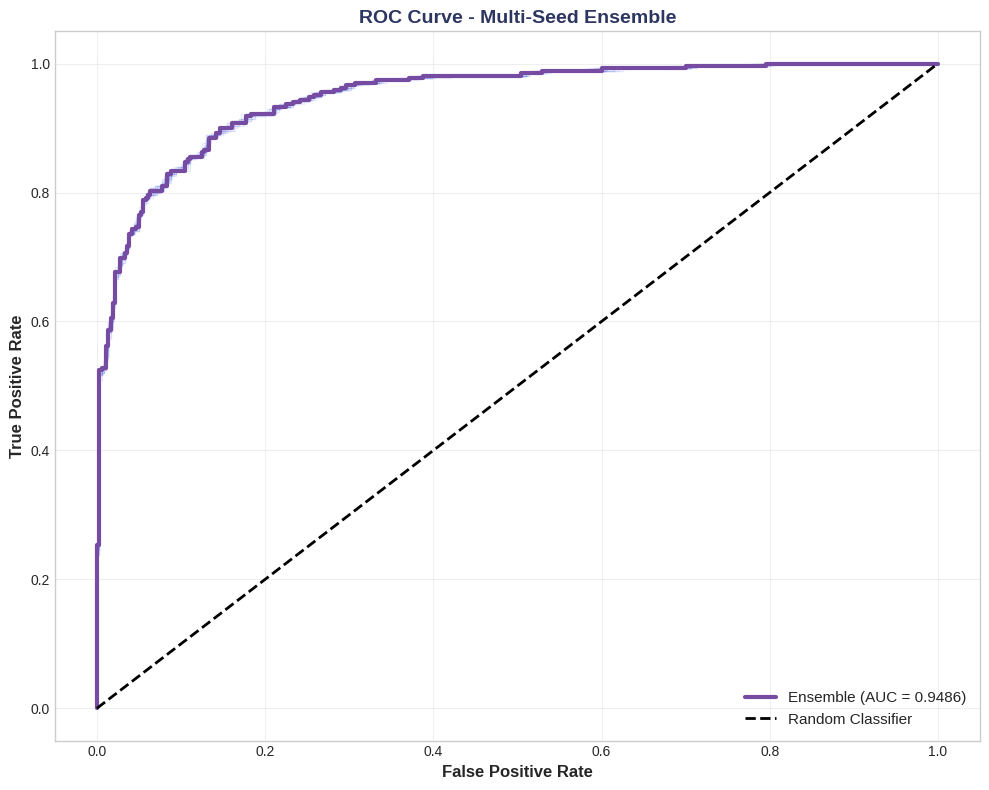

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (model_name, val_pred) in enumerate(zip(models.keys(), val_predictions)):
    fpr, tpr, _ = roc_curve(val_labels, val_pred)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, alpha=0.15, linewidth=1, color=COLORS['primary'])

fpr_ensemble, tpr_ensemble, _ = roc_curve(val_labels, val_ensemble)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

ax.plot(fpr_ensemble, tpr_ensemble, color=COLORS['secondary'], linewidth=3, 
        label=f'Ensemble (AUC = {roc_auc_ensemble:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Multi-Seed Ensemble', fontsize=14, fontweight='bold', color=COLORS['dark'])
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance

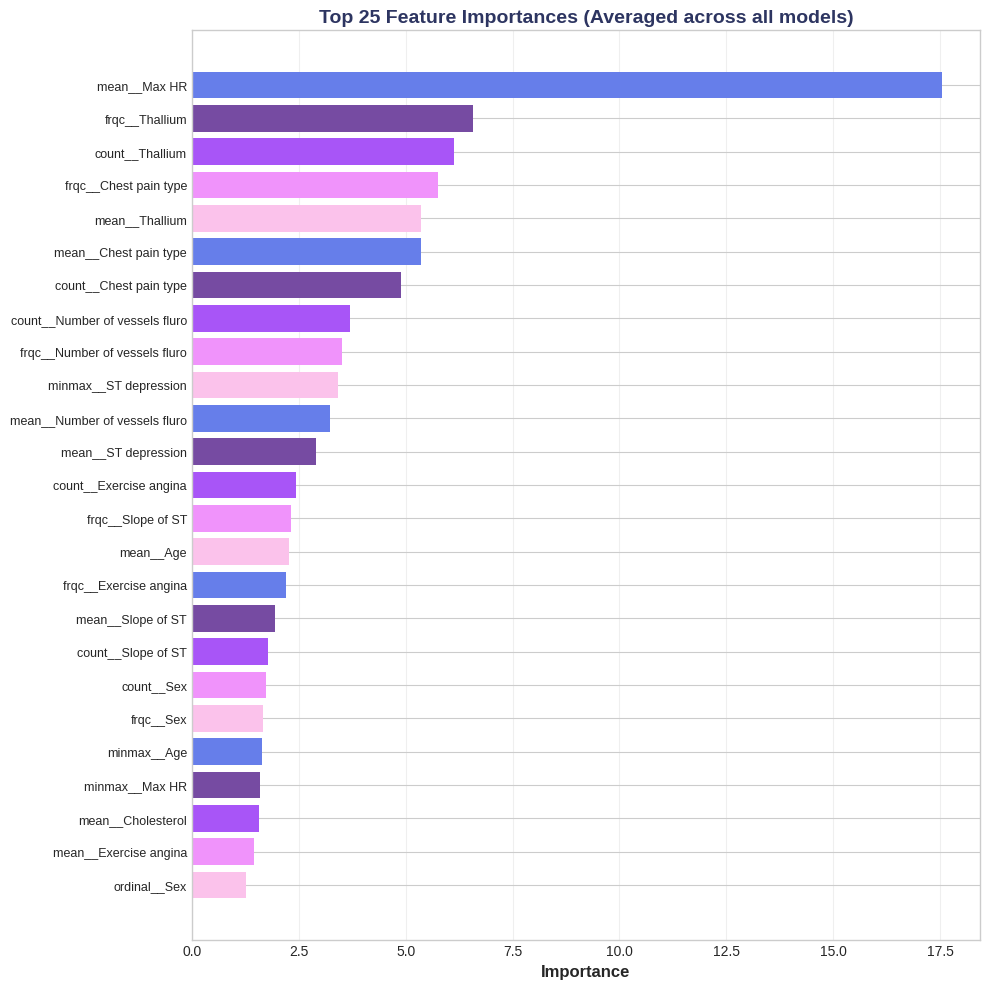

In [9]:
feature_importances = []
for model in models.values():
    feature_importances.append(model.feature_importances_)

avg_importance = np.mean(feature_importances, axis=0)
feature_names = train_prepared.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': avg_importance
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(range(len(importance_df)), importance_df['importance'], 
               color=[GRADIENT[i % len(GRADIENT)] for i in range(len(importance_df))])
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 25 Feature Importances (Averaged across all models)', 
             fontsize=14, fontweight='bold', color=COLORS['dark'])
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Test Prediction & Submission

In [10]:
test_prepared = preprocessing.transform(test)
test_prepared[ordinal_columns] = test_prepared[ordinal_columns].astype(str).astype('category')

test_predictions = []
for model in models.values():
    test_pred = model.predict_proba(test_prepared)[:,1]
    test_predictions.append(test_pred)

test_ensemble = np.mean(test_predictions, axis=0)

submission_df = test[['id']].copy()
submission_df['Heart Disease'] = test_ensemble
submission_df.to_csv("submission.csv", index=False)

print("✅ Submission saved successfully!")
submission_df.head(10)

✅ Submission saved successfully!


,id,Heart Disease
0,630000,0.957873
1,630001,0.008377
2,630002,0.992677
3,630003,0.004454
4,630004,0.230180
5,630005,0.988265
6,630006,0.004329
7,630007,0.610444
8,630008,0.993679
9,630009,0.013820


## Conclusion

**Strategy Implementation:**
- 3-seed × 5-fold cross-validation = 15 models ensemble
- Reduces variance through diverse random initialization
- Improves generalization and leaderboard stability

**Key Engineering Techniques:**
1. Target encoding with smoothing via global statistics
2. Frequency encoding for categorical features
3. KBins discretization for numerical features
4. CatBoost native categorical handling